## Testing Bias Mapping

### Avalaible data:
* Observations
* ERA5 (historical)
* CMIP (historical)
* CMIP (future)

### Possible bias correcting methods:
* method1
* method2
* method3

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from ewatercycle.observation.grdc import get_grdc_data
import xarray as xr
import pandas as pd

import seaborn as sns

### Import Data

#### Observations

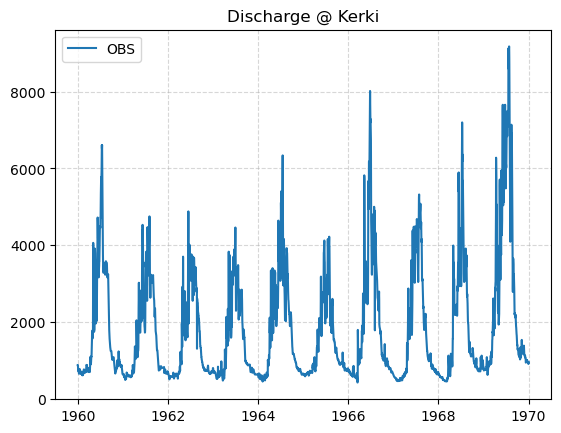

In [66]:
# Import Data

ds = get_grdc_data('2617110',
                   '1960-01-01T00:00Z',
                   '1970-01-01T00:00Z',
                   data_home = "../../data/GRDC/Daily")



obs = ds['streamflow'].to_pandas()
plt.plot(obs.index, obs.values, label = "OBS")
plt.title('Discharge @ Kerki')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

#### ERA5

In [67]:
file_era5 = "../../model_runs/HBV/ensemble_full/HBV_Kerki_ensemble_5020_m3s.nc"
sim_era5 = xr.open_dataset(file_era5)
sim_era5.close()

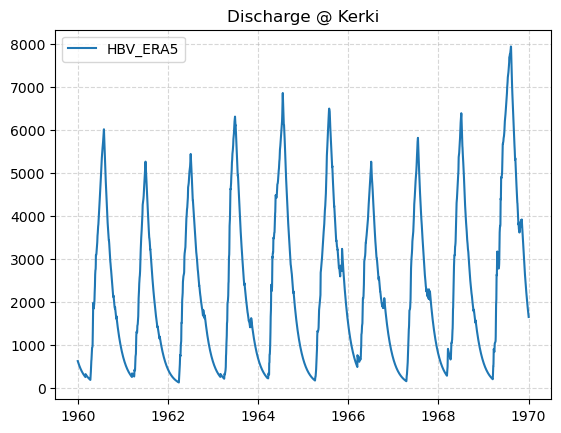

In [68]:
sim_era5_1= sim_era5.sel(particle = 1).sel(time= slice("1960-01-01","1970-01-01"))
sim_era5_1
plt.plot(sim_era5_1['time'], sim_era5_1['discharge'], label = 'HBV_ERA5')
plt.title('Discharge @ Kerki')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()



#### CMIP Historical

In [69]:
file_cmip = "../../model_runs/HBV/CMIP_runs/HBV_Kerki_ensemble_CMIP_historical_m3s.nc"
sim_cmip = xr.open_dataset(file_cmip)
sim_cmip.close()

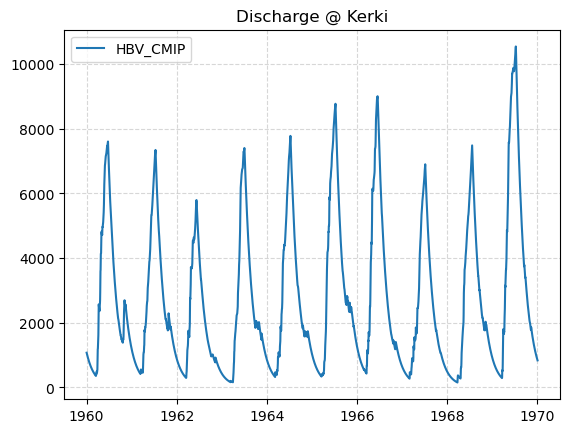

In [70]:
sim_cmip_1= sim_cmip.sel(particle = 1).sel(time= slice("1960-01-01","1970-01-01"))
sim_cmip_1
plt.plot(sim_cmip_1['time'], sim_cmip_1['discharge'], label = 'HBV_CMIP')
plt.title('Discharge @ Kerki')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()



#### CMIP Future

In [71]:
file_cmip_future = "../../model_runs/HBV/CMIP_runs/HBV_Kerki_ensemble_CMIP_future_m3s.nc"
sim_cmip_f = xr.open_dataset(file_cmip_future)
sim_cmip_f.close()

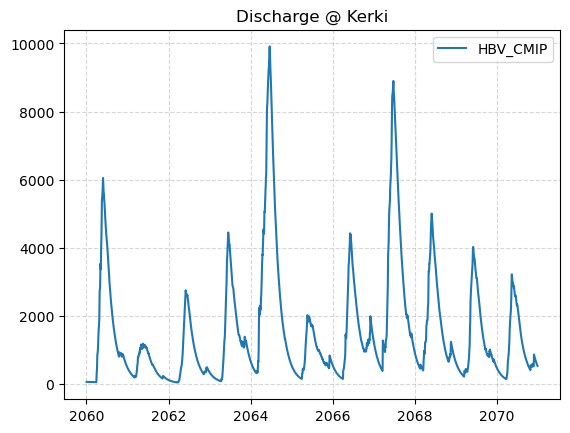

In [72]:
sim_cmip_f1= sim_cmip_f.sel(particle = 1)
sim_cmip_f1
plt.plot(sim_cmip_f1['time'], sim_cmip_f1['discharge'], label = 'HBV_CMIP')
plt.title('Discharge @ Kerki')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()



In [73]:
sim_cmip_1['discharge'].to_pandas()
sim_era5_1['discharge'].to_pandas()
sim_cmip_f1['discharge'].to_pandas()

time
2060-01-02 12:00:00     67.465133
2060-01-03 12:00:00     67.377678
2060-01-04 12:00:00     67.290279
2060-01-05 12:00:00     67.202837
2060-01-06 12:00:00     67.115415
                          ...    
2070-12-27 12:00:00    568.263988
2070-12-28 12:00:00    559.754541
2070-12-29 12:00:00    551.380262
2070-12-30 12:00:00    543.138970
2070-12-31 12:00:00    535.028449
Name: discharge, Length: 4017, dtype: float64

### Combined plot

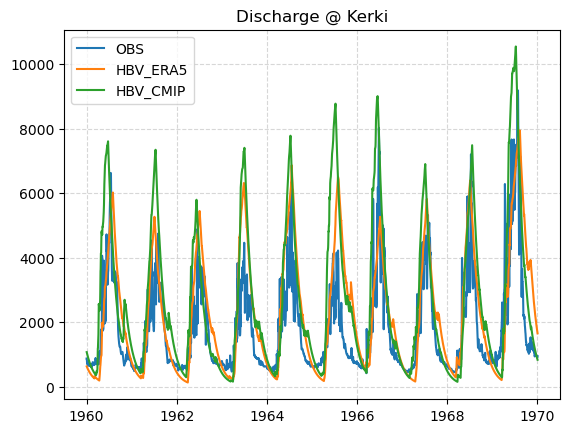

In [74]:
plt.plot(obs.index, obs.values, label = "OBS")
plt.plot(sim_era5_1['time'], sim_era5_1['discharge'], label = 'HBV_ERA5')
plt.plot(sim_cmip_1['time'], sim_cmip_1['discharge'], label = 'HBV_CMIP')
plt.title('Discharge @ Kerki')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()



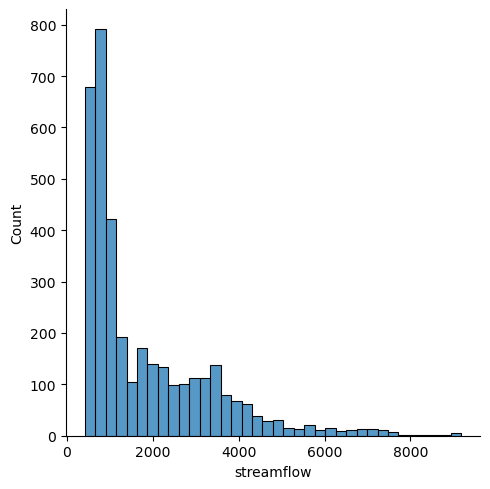

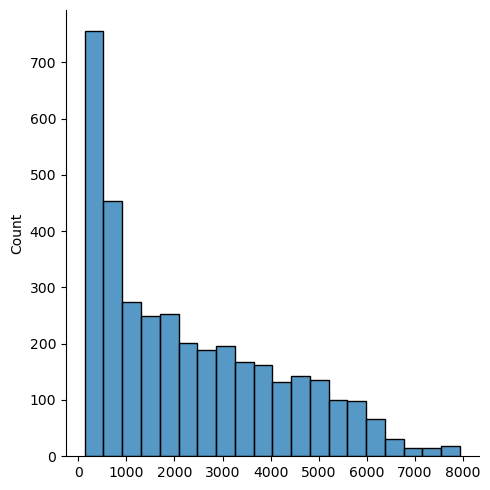

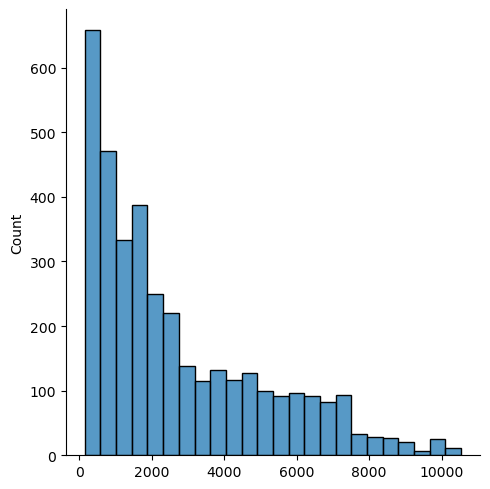

In [75]:
sns.displot(obs)
sns.displot(sim_era5_1['discharge'])
sns.displot(sim_cmip_1['discharge'])

In [76]:
sim_era5_1

<xarray.Dataset> Size: 58kB
Dimensions:    (time: 3654)
Coordinates:
  * time       (time) datetime64[ns] 29kB 1960-01-01T12:00:00 ... 1970-01-01T...
    particle   int64 8B 1
Data variables:
    discharge  (time) float64 29kB 629.1 619.8 610.6 ... 1.68e+03 1.654e+03

<Axes: xlabel='Discharge', ylabel='Count'>

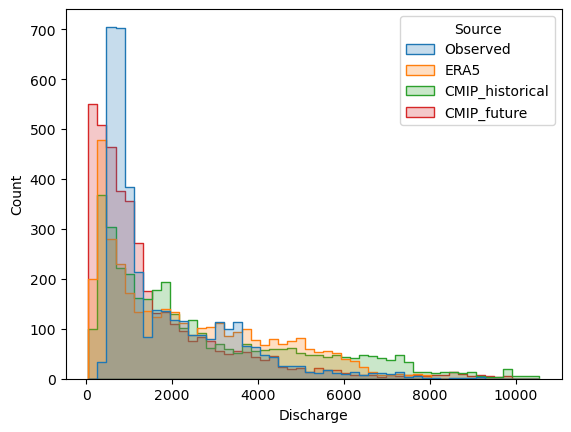

In [77]:
df = pd.concat([
    obs.rename("Observed"),
    sim_era5_1['discharge'].to_pandas().rename("ERA5"),
    sim_cmip_1['discharge'].to_pandas().rename("CMIP_historical"),
    sim_cmip_f1['discharge'].to_pandas().rename("CMIP_future")
], axis=1)

df_long = df.melt(var_name="Source", value_name="Discharge")


sns.histplot(
    data=df_long,
    x="Discharge",
    hue="Source",
    bins=50,
    element="step",
    common_norm=False
)

In [78]:
df = df.resample("1D").mean()
df.head()

,Observed,ERA5,CMIP_historical,CMIP_future
time,,,,
1960-01-01,875.0,629.127442,1072.037129,NaN
1960-01-02,875.0,619.790821,1055.757452,NaN
1960-01-03,798.0,610.601525,1039.736020,NaN
1960-01-04,770.0,601.557212,1023.968643,NaN
1960-01-05,722.0,592.655628,1008.451361,NaN


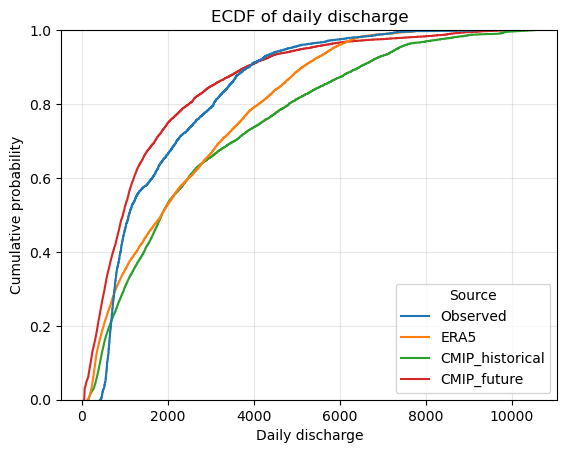

In [79]:
df_long = df.reset_index().melt(id_vars='time', var_name='Source', value_name='Discharge')

sns.ecdfplot(data=df_long, x='Discharge', hue='Source')
plt.xlabel("Daily discharge")
plt.ylabel("Cumulative probability")
plt.title("ECDF of daily discharge")
plt.grid(alpha=0.3)
plt.show()


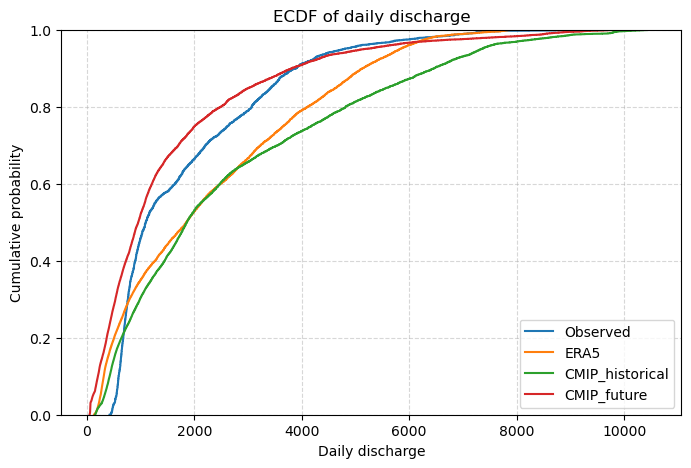

In [80]:


plt.figure(figsize=(8,5))

sns.ecdfplot(df['Observed'], label="Observed")
sns.ecdfplot(df['ERA5'], label="ERA5")
sns.ecdfplot(df['CMIP_historical'], label="CMIP_historical")
sns.ecdfplot(df['CMIP_future'], label="CMIP_future")

plt.xlabel("Daily discharge")
plt.ylabel("Cumulative probability")
plt.title("ECDF of daily discharge")
plt.legend()
plt.grid(linestyle = '--', alpha=0.5)
plt.show()

In [81]:
!pip install python-cmethods

Defaulting to user installation because normal site-packages is not writeable


In [82]:
from cmethods import adjust



In [83]:

df_d = df.copy() #(dropna?)

# convert daily aligned pandas to xarray DataArrays with explicit names
ds_obsh = xr.Dataset(
    data_vars={
        "discharge": ("time", df_d['Observed'].values)
    },
    coords={
        "time": df_d.index
    }
)

ds_simh = xr.Dataset(
    data_vars={
        "discharge": ("time", df_d['CMIP_historical'].values)
    },
    coords={
        "time": df_d.index
    }
)

ds_simp = xr.Dataset(
    data_vars={
        "discharge": ("time", df_d['CMIP_future'].values)
    },
    coords={
        "time": df_d.index
    }
)


ds_simp

<xarray.Dataset> Size: 649kB
Dimensions:    (time: 40543)
Coordinates:
  * time       (time) datetime64[ns] 324kB 1960-01-01 1960-01-02 ... 2070-12-31
Data variables:
    discharge  (time) float64 324kB nan nan nan nan ... 559.8 551.4 543.1 535.0

In [ ]:
qdm_adjusted = adjust(
    method="quantile_delta_mapping",
    obs=ds_obsh['discharge'],
    simh=ds_simh['discharge'],
    simp=ds_simp['discharge'],
    n_quantiles=250,
    kind="*"
)

linear_scaling = adjust(
    method="linear_scaling",
    obs=ds_obsh['discharge'],
    simh=ds_simh['discharge'],
    simp=ds_simp['discharge'],
    kind="*",
    group="time.month"
)

variance_scaling = adjust(
    method="variance_scaling",
    obs=ds_obsh['discharge'],
    simh=ds_simh['discharge'],
    simp=ds_simp['discharge'],
    kind="+",
    group="time.month"
)

delta_scaling = adjust(
    method="delta_method",
    obs=ds_obsh['discharge'],
    simh=ds_simh['discharge'],
    simp=ds_simp['discharge'],
    kind="*",
    group="time.month"

)

qm_adjusted = adjust(
    method="quantile_mapping",
    obs=ds_obsh['discharge'],
    simh=ds_simh['discharge'],
    simp=ds_simp['discharge'],
    n_quantiles=250,
    kind="*",

)



In [ ]:
qdm_adjusted

,Observed,ERA5,CMIP_historical,CMIP_future
time,,,,
1960-01-01,875.0,629.127442,1072.037129,NaN
1960-01-02,875.0,619.790821,1055.757452,NaN
1960-01-03,798.0,610.601525,1039.736020,NaN
1960-01-04,770.0,601.557212,1023.968643,NaN
1960-01-05,722.0,592.655628,1008.451361,NaN
...,...,...,...,...
2070-12-27,NaN,NaN,NaN,568.263988
2070-12-28,NaN,NaN,NaN,559.754541
2070-12-29,NaN,NaN,NaN,551.380262


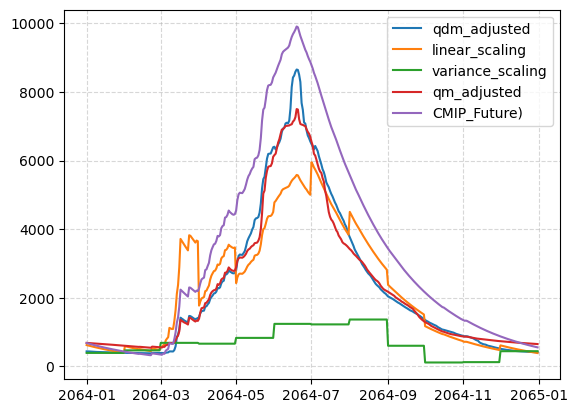

In [94]:
def plot_year(ds, label, year):
    ds_y = ds.sel(time=str(year))
    plt.plot(ds_y['time'], ds_y['discharge'], label=label)

year_to_plot = 2064

plot_year(qdm_adjusted, "qdm_adjusted", year_to_plot)
plot_year(linear_scaling, "linear_scaling", year_to_plot)
plot_year(variance_scaling, "variance_scaling", year_to_plot)
plot_year(qm_adjusted, "qm_adjusted", year_to_plot)

cmip_2064 = df.loc["2064", "CMIP_future"]
plt.plot(cmip_2064.index, cmip_2064, label="CMIP_Future)")

plt.grid(linestyle='--', alpha=0.5)
plt.legend()


In [ ]:
plt.figure(figsize=(10,6))  # width=10, height=6 inches
plt.plot(obs.index, obs.values, label = "OBS")
plt.plot(sim_era5_1['time'], sim_era5_1['discharge'], label = 'HBV_ERA5')
plt.plot(sim_cmip_1['time'], sim_cmip_1['discharge'], label = 'HBV_CMIP')
plt.plot(qdm_adjusted['time'], qdm_adjusted['discharge'],label='CMIP_QDM_adjusted')
plt.title('Discharge @ Kerki')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()



In [ ]:

plt.figure(figsize=(8,5))

sns.ecdfplot(df['Observed'], label="Observed")
sns.ecdfplot(df['CMIP_historical'], label="CMIP_historical")
sns.ecdfplot(df['CMIP_future'], label="CMIP_future")
sns.ecdfplot(qdm_adjusted['discharge'], label="qdm_adjusted")


plt.xlabel("Daily discharge")
plt.ylabel("Cumulative probability")
plt.title("ECDF of daily discharge")
plt.legend()
plt.grid(linestyle = '--', alpha=0.5)
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df_long, x="Discharge", hue="Source", fill=False,bw_adjust=.25)
plt.xlabel("Daily discharge")
plt.ylabel("Density")
plt.title("KDE of daily discharge")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
sns.displot(df_long, x="Discharge", hue="Source", kind="ecdf")

In [ ]:
df_long

In [ ]:
df

In [ ]:
qdm_trimmed = qdm_adjusted.dropna(dim="time")

qdm_series = (
    qdm_trimmed["discharge"]
    .to_pandas()
    .rename("CMIP_QDM")
)

In [ ]:
qdm_trimmed

In [ ]:
df = pd.concat([
    obs.rename("Observed"),
    sim_era5_1["discharge"].to_pandas().rename("ERA5"),
    sim_cmip_1["discharge"].to_pandas().rename("CMIP_historical"),
    sim_cmip_f1["discharge"].to_pandas().rename("CMIP_future"),
    qdm_series
], axis=1)

df = df.resample("1D").mean()
df.head()

df_long = df.melt(var_name="Source", value_name="Discharge")

In [ ]:
plt.plot(df.index, df["CMIP_future"], label="CMIP future")
plt.plot(df.index, df["CMIP_QDM"], label="CMIP QDM")
plt.grid(linestyle='--',alpha=0.5)
plt.title('results QDM correction CMIP-Future for GRDC Kerki')
plt.xlabel('time')
plt.ylabel('discharge [m3/s]')
plt.legend()

<Axes: xlabel='Discharge', ylabel='Count'>

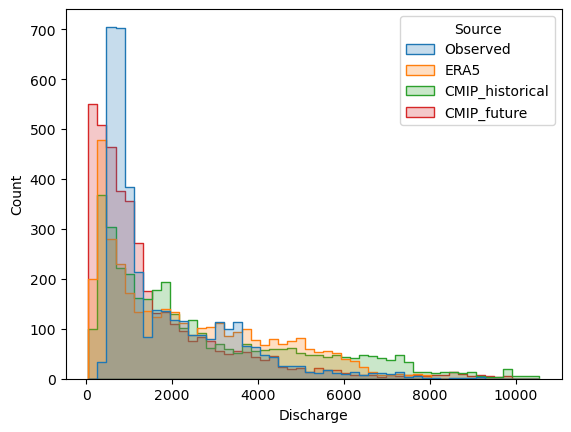

In [95]:
sns.histplot(
    data=df_long,
    x="Discharge",
    hue="Source",
    bins=50,
    element="step",
    common_norm=False
)

In [96]:
from cmethods import adjust

def run_bias_corrections(
    obs,
    simh,
    simp,
    n_quantiles=250,
    group_monthly="time.month"
):
    """
    Run a standard suite of bias-correction methods using cmethods.adjust.

    Parameters
    ----------
    obs : xarray.DataArray
        Observations (historical)
    simh : xarray.DataArray
        Historical simulation
    simp : xarray.DataArray
        Future simulation
    n_quantiles : int
        Number of quantiles for QM / QDM
    group_monthly : str
        Grouping for seasonal methods (e.g. 'time.month')

    Returns
    -------
    dict[str, xarray.DataArray]
        Dictionary with bias-corrected future simulations
    """

    results = {}

    results["qdm"] = adjust(
        method="quantile_delta_mapping",
        obs=obs,
        simh=simh,
        simp=simp,
        n_quantiles=n_quantiles,
        kind="*"
    )

    results["linear_scaling"] = adjust(
        method="linear_scaling",
        obs=obs,
        simh=simh,
        simp=simp,
        kind="*",
        group=group_monthly
    )

    results["variance_scaling"] = adjust(
        method="variance_scaling",
        obs=obs,
        simh=simh,
        simp=simp,
        kind="+",
        group=group_monthly
    )

    results["delta_scaling"] = adjust(
        method="delta_method",
        obs=obs,
        simh=simh,
        simp=simp,
        kind="*",
        group=group_monthly
    )

    results["qm"] = adjust(
        method="quantile_mapping",
        obs=obs,
        simh=simh,
        simp=simp,
        n_quantiles=n_quantiles,
        kind="*"
    )

    return results


In [ ]:

df_d = df.copy() #(dropna?)

# convert daily aligned pandas to xarray DataArrays with explicit names
ds_obsh = xr.Dataset(
    data_vars={
        "discharge": ("time", df_d['Observed'].values)
    },
    coords={
        "time": df_d.index
    }
)

ds_simh = xr.Dataset(
    data_vars={
        "discharge": ("time", df_d['ERA5'].values)
    },
    coords={
        "time": df_d.index
    }
)

ds_simp = xr.Dataset(
    data_vars={
        "discharge": ("time", df_d['CMIP_historical'].values)
    },
    coords={
        "time": df_d.index
    }
)




<xarray.Dataset> Size: 649kB
Dimensions:    (time: 40543)
Coordinates:
  * time       (time) datetime64[ns] 324kB 1960-01-01 1960-01-02 ... 2070-12-31
Data variables:
    discharge  (time) float64 324kB 1.072e+03 1.056e+03 1.04e+03 ... nan nan nan

In [98]:
bc = run_bias_corrections(
    obs=ds_obsh["discharge"],
    simh=ds_simh["discharge"],
    simp=ds_simp["discharge"]
)

qdm_adjusted      = bc["qdm"]
linear_scaling    = bc["linear_scaling"]
variance_scaling  = bc["variance_scaling"]
delta_scaling     = bc["delta_scaling"]
qm_adjusted       = bc["qm"]

In [114]:
ds_simh["discharge"]

<xarray.DataArray 'discharge' (time: 40543)> Size: 324kB
array([629.12744167, 619.79082069, 610.60152473, ...,          nan,
                nan,          nan])
Coordinates:
  * time     (time) datetime64[ns] 324kB 1960-01-01 1960-01-02 ... 2070-12-31

In [109]:
def plot_year_xr(ds, label, year, var="discharge"):
    da_y = ds[var].sel(time=str(year))
    plt.plot(da_y.time, da_y, label=label, alpha=0.8)

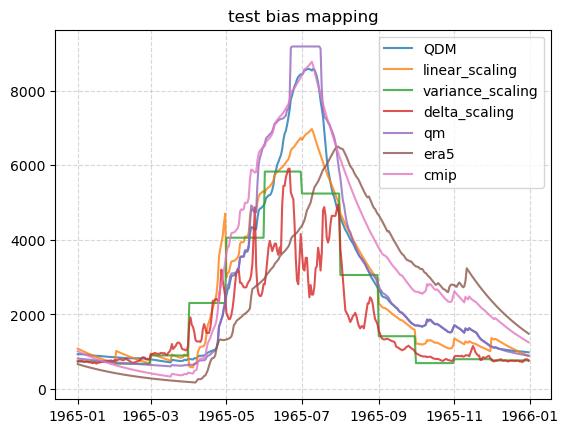

In [117]:
plot_year_xr(bc["qdm"], "QDM", 1965)
plot_year_xr(bc["linear_scaling"], "linear_scaling", 1965)
plot_year_xr(bc["variance_scaling"], "variance_scaling", 1965)
plot_year_xr(bc["delta_scaling"], "delta_scaling", 1965)
plot_year_xr(bc["qm"], "qm", 1965)
plot_year_xr(ds_simh, "era5", 1965)
plot_year_xr(ds_simp, "cmip", 1965)
plt.grid(linestyle="--",alpha=0.5)
plt.title("test bias mapping")
plt.legend()

In [103]:
qm_adjusted

<xarray.Dataset> Size: 649kB
Dimensions:    (time: 40543)
Coordinates:
  * time       (time) datetime64[ns] 324kB 1960-01-01 1960-01-02 ... 2070-12-31
Data variables:
    discharge  (time) float64 324kB 844.9 837.3 829.7 823.5 ... nan nan nan nan
Attributes:
    cmethods_version:      2.3.2
    cmethods_method:       quantile_mapping
    cmethods_timestamp:    2026-01-13 10:27:44 UTC
    cmethods_source:       https://github.com/btschwertfeger/python-cmethods
    cmethods_kind:         *
    cmethods_n_quantiles:  250

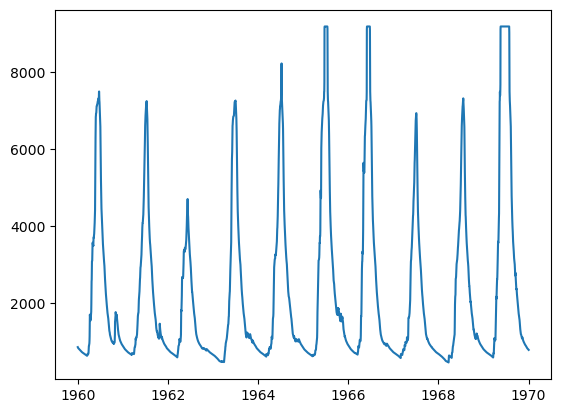

In [104]:
plt.plot(qm_adjusted['time'],qm_adjusted['discharge'])